## Imports e configurações

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import os
import json
import time
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    hamming_loss
)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

RANDOM_STATE = 42
N_JOBS = -1
DATA_DIR = Path("../data/treated")
N_OUTER_FOLDS = 5

EMOTION_COLS = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]

TEXT_COL = 'CLEAN_TEXT'

print(f"Emotion labels : {len(EMOTION_COLS)}")
print(f"Data directory : {DATA_DIR.resolve()}")

Emotion labels : 28
Data directory : C:\Users\luan.barbosa\Desktop\Luan\Aleatório\TCC\tcc-emotion-detection-nlp\data\treated


## Carregamento dos folds

In [5]:
def load_fold(fold_id: int):
    """
    Carrega data.parquet e idx.npy de um fold.
    Retorna (df, idx_array).
    """
    fold_dir = DATA_DIR / f"fold_{fold_id}"
    df  = pd.read_parquet(fold_dir / "data.parquet")
    idx = np.load(fold_dir / "idx.npy")
    return df, idx

# Verifica disponibilidade dos folds
folds_data = {}
for k in range(1, N_OUTER_FOLDS + 1):
    df_k, idx_k = load_fold(k)
    folds_data[k] = {"df": df_k, "idx": idx_k}
    print(f"Fold {k}: {df_k.shape[0]:>6} amostras | idx shape: {idx_k.shape}")

# Inspeciona colunas do primeiro fold
print("\nColunas disponíveis:", folds_data[1]["df"].columns.tolist())

Fold 1:  10831 amostras | idx shape: (10831,)
Fold 2:  10810 amostras | idx shape: (10810,)
Fold 3:  10836 amostras | idx shape: (10836,)
Fold 4:  10909 amostras | idx shape: (10909,)
Fold 5:  10848 amostras | idx shape: (10848,)

Colunas disponíveis: ['id', 'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral', 'text', 'texto', 'UNCLEAN_TEXT', 'CLEAN_TEXT', 'letter_count', 'sentence_count', 'avg_letter_per_word', 'words_per_sentence', 'avg_syllables_per_word', 'reading_time', 'punctuation_per_word', 'exclamation_per_word', 'question_per_word', 'mean_verbs_per_word', 'mean_auxiliaries_per_word', 'mean_auxiliaries_per_sentence', 'flesch_portuguese', 'uppercase_percentage', 'mean_unique_word_length', 'mean_char_rep

## Funções auxiliares

In [6]:
def prepare_Xy(df: pd.DataFrame):
    X_text = df[TEXT_COL].fillna("").astype(str).values
    present_cols = [c for c in EMOTION_COLS if c in df.columns]
    Y = df[present_cols].values.astype(int)
    return X_text, Y, present_cols

def inner_gridsearch_per_label(
    X_train_text: np.ndarray,
    y_train_label: np.ndarray,
    n_inner_splits: int = 3,
):
    """
    Executa GridSearchCV no conjunto de treino (inner loop) para
    um único label binário.  Retorna os melhores hiperparâmetros.
    """
    # Grade de hiperparâmetros
    param_grid = {
        "tfidf__max_features" : [10_000, 30_000, None],
        "tfidf__ngram_range"  : [(1, 1), (1, 2)],
        "tfidf__sublinear_tf" : [True, False],
        "lr__C"               : [0.01, 0.1, 1.0, 10.0],
        "lr__solver"          : ["saga"],
        "lr__max_iter"        : [1000],
    }

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("lr",   LogisticRegression(random_state=RANDOM_STATE)),
    ])

    # Só faz CV se há amostras positivas suficientes
    n_pos = y_train_label.sum()
    if n_pos < n_inner_splits:
        # Fallback: parâmetros padrão
        return {
            "tfidf__max_features" : 30_000,
            "tfidf__ngram_range"  : (1, 2),
            "tfidf__sublinear_tf" : True,
            "lr__C"               : 1.0,
            "lr__solver"          : "saga",
            "lr__max_iter"        : 1000,
        }

    cv_inner = StratifiedKFold(
        n_splits=n_inner_splits, shuffle=True, random_state=RANDOM_STATE
    )

    gs = GridSearchCV(
        pipe,
        param_grid,
        cv=cv_inner,
        scoring="f1",
        n_jobs=N_JOBS,
        refit=False,   # só queremos os params; o treino final é feito fora
        error_score=0.0,
    )
    gs.fit(X_train_text, y_train_label)
    return gs.best_params_

def train_predict_binary_relevance(
    X_train_text : np.ndarray,
    Y_train : np.ndarray,
    X_test_text : np.ndarray,
    best_params_per_label: dict,
    label_names : list,
):
    """
    Para cada label:
      1. Vetoriza texto com TF-IDF (params otimizados no inner)
      2. Aplica SMOTE na representação esparsa
      3. Treina LR
      4. Prediz no teste

    Retorna Y_pred (N_test × n_labels) e Y_proba (N_test × n_labels).
    """
    n_labels = Y_train.shape[1]
    n_test = X_test_text.shape[0]

    Y_pred = np.zeros((n_test, n_labels), dtype=int)
    Y_proba = np.zeros((n_test, n_labels), dtype=float)

    for j, label_name in enumerate(label_names):
        y_j = Y_train[:, j]
        params = best_params_per_label.get(label_name, {})

        # --- TF-IDF ---
        tfidf = TfidfVectorizer(
            max_features = params.get("tfidf__max_features", 30_000),
            ngram_range  = params.get("tfidf__ngram_range",  (1, 2)),
            sublinear_tf = params.get("tfidf__sublinear_tf", True),
        )
        X_tr_vec = tfidf.fit_transform(X_train_text)
        X_te_vec = tfidf.transform(X_test_text)

        # --- SMOTE ---
        n_pos = y_j.sum()
        n_neg = len(y_j) - n_pos
        if n_pos >= 2 and n_neg >= 2:
            k_neighbors = min(5, n_pos - 1)
            smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_neighbors)
            X_tr_res, y_j_res = smote.fit_resample(X_tr_vec, y_j)
        else:
            X_tr_res, y_j_res = X_tr_vec, y_j

        # --- Logistic Regression ---
        lr = LogisticRegression(
            C = params.get("lr__C", 1.0),
            solver = params.get("lr__solver", "saga"),
            max_iter = params.get("lr__max_iter", 1000),
            random_state = RANDOM_STATE,
        )
        lr.fit(X_tr_res, y_j_res)

        Y_pred[:, j]  = lr.predict(X_te_vec)
        Y_proba[:, j] = lr.predict_proba(X_te_vec)[:, 1]

    return Y_pred, Y_proba

def compute_metrics(Y_true, Y_pred, Y_proba, label_names):
    metrics = {
        "accuracy": accuracy_score(Y_true, Y_pred),
        "hamming_loss": hamming_loss(Y_true, Y_pred),
        "f1_macro": f1_score(Y_true, Y_pred, average="macro",    zero_division=0),
        "f1_micro": f1_score(Y_true, Y_pred, average="micro",    zero_division=0),
        "f1_weighted": f1_score(Y_true, Y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(Y_true, Y_pred, average="macro",    zero_division=0),
        "recall_macro": recall_score(Y_true, Y_pred, average="macro",    zero_division=0),
    }

    # ROC-AUC macro (ignora labels sem positivos no teste)
    valid_cols = [j for j in range(Y_true.shape[1]) if Y_true[:, j].sum() > 0]
    if valid_cols:
        metrics["roc_auc_macro"] = roc_auc_score(
            Y_true[:, valid_cols], Y_proba[:, valid_cols], average="macro"
        )
    else:
        metrics["roc_auc_macro"] = np.nan

    # F1 por label
    f1_per_label = f1_score(Y_true, Y_pred, average=None, zero_division=0)
    metrics["f1_per_label"] = dict(zip(label_names, f1_per_label))

    return metrics

## Nested CV — loop principal

Cada fold `k` é o **outer test**; os demais `K-1` folds formam o **outer train**.
Dentro do outer-train, um **inner GridSearchCV** (3-fold estratificado por label)
seleciona os melhores hiperparâmetros antes de treinar o modelo final.

In [7]:
all_fold_metrics = []
all_best_params  = {}   # {outer_fold: {label: params}}

for outer_k in range(1, N_OUTER_FOLDS + 1):
    t0 = time.time()
    print(f"\n{'='*60}")
    print(f"  OUTER FOLD {outer_k}/{N_OUTER_FOLDS}")
    print(f"{'='*60}")

    # ── Separa outer-test ──────────────────────────────────────
    df_test_outer, _ = load_fold(outer_k)
    X_test_text, Y_test, label_names = prepare_Xy(df_test_outer)

    # ── Concatena outer-train (demais folds) ──────────────────
    train_dfs = [
        folds_data[k]["df"]
        for k in range(1, N_OUTER_FOLDS + 1)
        if k != outer_k
    ]
    df_train_outer = pd.concat(train_dfs, ignore_index=True)
    X_train_text, Y_train, _ = prepare_Xy(df_train_outer)

    print(f"  Treino: {len(X_train_text):>6} | Teste: {len(X_test_text):>5}")

    # ── Inner GridSearch por label ─────────────────────────────
    print("  [Inner CV] Otimizando hiperparâmetros por label...")
    best_params_this_fold = {}

    for j, lname in enumerate(label_names):
        y_j = Y_train[:, j]
        bp = inner_gridsearch_per_label(
            X_train_text, y_j, n_inner_splits=3
        )
        best_params_this_fold[lname] = bp

    all_best_params[outer_k] = best_params_this_fold
    print("  [Inner CV] Concluído.")

    # ── Treino final + predição (Binary Relevance + SMOTE) ────
    print("  [Outer] Treinando modelo final e predizendo...")
    Y_pred, Y_proba = train_predict_binary_relevance(
        X_train_text, Y_train,
        X_test_text,
        best_params_this_fold,
        label_names,
    )

    # ── Reconstrução da matriz de targets e cálculo das métricas
    # Garante alinhamento de colunas
    assert Y_pred.shape == Y_test.shape, (
        f"Shape mismatch: pred={Y_pred.shape} vs true={Y_test.shape}"
    )

    fold_metrics = compute_metrics(Y_test, Y_pred, Y_proba, label_names)
    fold_metrics["outer_fold"] = outer_k
    fold_metrics["elapsed_s"]  = round(time.time() - t0, 1)
    all_fold_metrics.append(fold_metrics)

    # Resumo rápido
    print(f"  F1-Macro   : {fold_metrics['f1_macro']:.4f}")
    print(f"  F1-Micro   : {fold_metrics['f1_micro']:.4f}")
    print(f"  ROC-AUC    : {fold_metrics['roc_auc_macro']:.4f}")
    print(f"  Tempo      : {fold_metrics['elapsed_s']}s")

print("\n✓ Nested CV concluído.")


  OUTER FOLD 1/5
  Treino:  43403 | Teste: 10831
  [Inner CV] Otimizando hiperparâmetros por label...
  [Inner CV] Concluído.
  [Outer] Treinando modelo final e predizendo...
  F1-Macro   : 0.3695
  F1-Micro   : 0.4159
  ROC-AUC    : 0.8375
  Tempo      : 2315.3s

  OUTER FOLD 2/5
  Treino:  43424 | Teste: 10810
  [Inner CV] Otimizando hiperparâmetros por label...
  [Inner CV] Concluído.
  [Outer] Treinando modelo final e predizendo...
  F1-Macro   : 0.3608
  F1-Micro   : 0.4114
  ROC-AUC    : 0.8414
  Tempo      : 2366.3s

  OUTER FOLD 3/5
  Treino:  43398 | Teste: 10836
  [Inner CV] Otimizando hiperparâmetros por label...
  [Inner CV] Concluído.
  [Outer] Treinando modelo final e predizendo...
  F1-Macro   : 0.3663
  F1-Micro   : 0.4241
  ROC-AUC    : 0.8395
  Tempo      : 2459.6s

  OUTER FOLD 4/5
  Treino:  43325 | Teste: 10909
  [Inner CV] Otimizando hiperparâmetros por label...
  [Inner CV] Concluído.
  [Outer] Treinando modelo final e predizendo...
  F1-Macro   : 0.3714
  F1-Mi

## Análise dos resultados

In [13]:
# ── Métricas globais por fold ────────────────────────────────────
global_metric_keys = [
    "outer_fold", "accuracy", "hamming_loss",
    "f1_macro", "f1_micro", "f1_weighted",
    "precision_macro", "recall_macro", "roc_auc_macro", "elapsed_s"
]

rows = [{k: m[k] for k in global_metric_keys} for m in all_fold_metrics]
df_results = pd.DataFrame(rows).set_index("outer_fold")

# Linha de média ± desvio-padrão
numeric_cols = [c for c in df_results.columns if c != "elapsed_s"]
mean_row = df_results[numeric_cols].mean().rename("mean")
std_row  = df_results[numeric_cols].std().rename("std")

df_summary = pd.concat([
    df_results[numeric_cols],
    mean_row.to_frame().T,
    std_row.to_frame().T
])

print("\n===== MÉTRICAS GLOBAIS POR OUTER FOLD =====")
display(df_results.round(4))

print("\n===== RESUMO (média ± desvio-padrão) =====")
display(df_summary.round(4))


===== MÉTRICAS GLOBAIS POR OUTER FOLD =====


,accuracy,hamming_loss,f1_macro,f1_micro,f1_weighted,precision_macro,recall_macro,roc_auc_macro,elapsed_s
outer_fold,,,,,,,,,
1,0.1980,0.0629,0.3695,0.4159,0.4652,0.3324,0.4560,0.8375,2315.3
2,0.1849,0.0644,0.3608,0.4114,0.4613,0.3172,0.4587,0.8414,2366.3
3,0.1935,0.0622,0.3663,0.4241,0.4692,0.3249,0.4729,0.8395,2459.6
4,0.1848,0.0639,0.3714,0.4142,0.4627,0.3324,0.4674,0.8395,2381.7
5,0.1753,0.0657,0.3596,0.4106,0.4608,0.3131,0.4711,0.8374,2423.2



===== RESUMO (média ± desvio-padrão) =====


,accuracy,hamming_loss,f1_macro,f1_micro,f1_weighted,precision_macro,recall_macro,roc_auc_macro
1,0.1980,0.0629,0.3695,0.4159,0.4652,0.3324,0.4560,0.8375
2,0.1849,0.0644,0.3608,0.4114,0.4613,0.3172,0.4587,0.8414
3,0.1935,0.0622,0.3663,0.4241,0.4692,0.3249,0.4729,0.8395
4,0.1848,0.0639,0.3714,0.4142,0.4627,0.3324,0.4674,0.8395
5,0.1753,0.0657,0.3596,0.4106,0.4608,0.3131,0.4711,0.8374
mean,0.1873,0.0638,0.3655,0.4152,0.4639,0.3240,0.4652,0.8390
std,0.0088,0.0013,0.0052,0.0054,0.0034,0.0088,0.0075,0.0017


In [14]:
# ── F1 por label (média entre folds) ────────────────────────────
f1_per_label_folds = pd.DataFrame(
    [m["f1_per_label"] for m in all_fold_metrics],
    index=[f"fold_{m['outer_fold']}" for m in all_fold_metrics]
)

f1_per_label_mean = f1_per_label_folds.mean().sort_values(ascending=False)

print("\n===== F1 POR LABEL (média entre folds) =====")
display(pd.DataFrame({
    "F1 Médio": f1_per_label_mean,
    "Std": f1_per_label_folds.std()
}).round(4))


===== F1 POR LABEL (média entre folds) =====


,F1 Médio,Std
admiration,0.6092,0.0105
amusement,0.7242,0.0080
anger,0.2993,0.0540
annoyance,0.2092,0.0172
approval,0.2080,0.0087
caring,0.2909,0.0221
confusion,0.2722,0.0601
curiosity,0.2179,0.0082
desire,0.4706,0.0285
disappointment,0.1650,0.0124


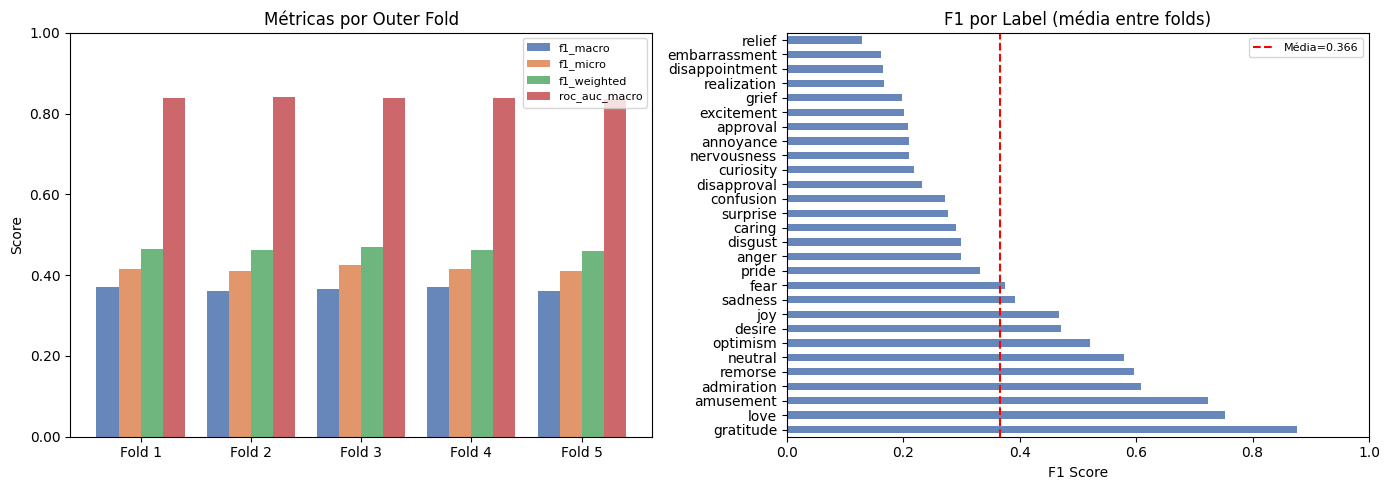

Figura salva em ../data/out/baseline_LR_metrics.png


In [15]:
# ── 6.1  F1-Macro por outer fold ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_plot = ["f1_macro", "f1_micro", "f1_weighted", "roc_auc_macro"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

ax = axes[0]
fold_labels = [f"Fold {k}" for k in df_results.index]

x = np.arange(len(df_results))
width = 0.20
for i, (met, col) in enumerate(zip(metric_plot, colors)):
    ax.bar(x + i * width, df_results[met], width, label=met, color=col, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(fold_labels)
ax.set_ylim(0, 1)
ax.set_title("Métricas por Outer Fold")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.set_ylabel("Score")

# ── 6.2  F1 por label ────────────────────────────────────────────
ax2 = axes[1]
f1_per_label_mean.plot.barh(ax=ax2, color="#4C72B0", alpha=0.85)
ax2.set_title("F1 por Label (média entre folds)")
ax2.set_xlabel("F1 Score")
ax2.set_xlim(0, 1)
ax2.axvline(f1_per_label_mean.mean(), color="red", linestyle="--", label=f"Média={f1_per_label_mean.mean():.3f}")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../data/out/baseline_LR_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura salva em ../data/out/baseline_LR_metrics.png")

In [16]:
# Agrega os params escolhidos por label em cada fold
param_keys = ["tfidf__max_features", "tfidf__ngram_range", "tfidf__sublinear_tf",
              "lr__C", "lr__solver"]

param_records = []
for fold_k, label_dict in all_best_params.items():
    for label, params in label_dict.items():
        row = {"fold": fold_k, "label": label}
        row.update({pk: params.get(pk) for pk in param_keys})
        param_records.append(row)

df_params = pd.DataFrame(param_records)

print("\n===== HIPERPARÂMETROS MAIS FREQUENTES =====")
for pk in param_keys:
    vc = df_params[pk].value_counts()
    print(f"  {pk}: {dict(vc.head(5))}")

display(df_params.head(10))


===== HIPERPARÂMETROS MAIS FREQUENTES =====
  tfidf__max_features: {10000.0: np.int64(92), 30000.0: np.int64(6)}
  tfidf__ngram_range: {(1, 2): np.int64(91), (1, 1): np.int64(49)}
  tfidf__sublinear_tf: {True: np.int64(98), False: np.int64(42)}
  lr__C: {10.0: np.int64(139), 0.01: np.int64(1)}
  lr__solver: {'saga': np.int64(140)}


,fold,label,tfidf__max_features,tfidf__ngram_range,tfidf__sublinear_tf,lr__C,lr__solver
0,1,admiration,NaN,"(1, 2)",True,10.0,saga
1,1,amusement,NaN,"(1, 2)",True,10.0,saga
2,1,anger,NaN,"(1, 2)",False,10.0,saga
3,1,annoyance,10000.0,"(1, 2)",True,10.0,saga
4,1,approval,10000.0,"(1, 2)",False,10.0,saga
5,1,caring,10000.0,"(1, 2)",False,10.0,saga
6,1,confusion,10000.0,"(1, 2)",False,10.0,saga
7,1,curiosity,10000.0,"(1, 2)",True,10.0,saga
8,1,desire,NaN,"(1, 2)",False,10.0,saga
9,1,disappointment,10000.0,"(1, 1)",False,10.0,saga


In [12]:
out_dir = Path("../data/out")
out_dir.mkdir(parents=True, exist_ok=True)

# Métricas globais
df_results.to_csv(out_dir / "baseline_LR_global_metrics.csv")

# Métricas por label
f1_per_label_folds.to_csv(out_dir / "baseline_LR_f1_per_label.csv")

# Melhores params
df_params.to_csv(out_dir / "baseline_LR_best_params.csv", index=False)

# Resumo final em JSON
summary_dict = {
    "model"       : "LogisticRegression + TF-IDF (Binary Relevance + SMOTE)",
    "strategy"    : "Nested CV (5 outer, 3 inner)",
    "n_labels"    : len(label_names),
    "f1_macro_mean"   : round(float(df_results["f1_macro"].mean()), 4),
    "f1_macro_std"    : round(float(df_results["f1_macro"].std()),  4),
    "f1_micro_mean"   : round(float(df_results["f1_micro"].mean()), 4),
    "f1_micro_std"    : round(float(df_results["f1_micro"].std()),  4),
    "roc_auc_mean"    : round(float(df_results["roc_auc_macro"].mean()), 4),
    "roc_auc_std"     : round(float(df_results["roc_auc_macro"].std()),  4),
}

with open(out_dir / "baseline_LR_summary.json", "w") as f:
    json.dump(summary_dict, f, indent=2)

print("Arquivos exportados para", out_dir.resolve())
print(json.dumps(summary_dict, indent=2))

Arquivos exportados para C:\Users\luan.barbosa\Desktop\Luan\Aleatório\TCC\tcc-emotion-detection-nlp\data\out
{
  "model": "LogisticRegression + TF-IDF (Binary Relevance + SMOTE)",
  "strategy": "Nested CV (5 outer, 3 inner)",
  "n_labels": 28,
  "f1_macro_mean": 0.3655,
  "f1_macro_std": 0.0052,
  "f1_micro_mean": 0.4152,
  "f1_micro_std": 0.0054,
  "roc_auc_mean": 0.839,
  "roc_auc_std": 0.0017
}
